<a href="https://colab.research.google.com/github/mbrinkl5/ECGR-4106---Introduction-to-Deep-Learning/blob/main/ECGR4106_HW_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.model_selection import train_test_split
import time
import pandas as pd

In [ ]:
!pip install thop

In [ ]:
from thop import profile

# **Problem 1: Character-Level Transformer vs. RNN Comparison**

Transformer Model

In [ ]:
text = """
Next character prediction is a fundamental task in the field of natural language processing (NLP) that involves predicting the next character in a sequence of text based on the characters that precede it. This task is essential for various applications, including text auto-completion, spell checking, and even in the development of sophisticated AI models capable of generating human-like text.

At its core, next character prediction relies on statistical models or deep learning algorithms to analyze a given sequence of text and predict which character is most likely to follow. These predictions are based on patterns and relationships learned from large datasets of text during the training phase of the model.

One of the most popular approaches to next character prediction involves the use of Recurrent Neural Networks (RNNs), and more specifically, a variant called Long Short-Term Memory (LSTM) networks. RNNs are particularly well-suited for sequential data like text, as they can maintain information in 'memory' about previous characters to inform the prediction of the next character. LSTM networks enhance this capability by being able to remember long-term dependencies, making them even more effective for next character prediction tasks.

Training a model for next character prediction involves feeding it large amounts of text data, allowing it to learn the probability of each character's appearance following a sequence of characters. During this training process, the model adjusts its parameters to minimize the difference between its predictions and the actual outcomes, thus improving its predictive accuracy over time.

Once trained, the model can be used to predict the next character in a given piece of text by considering the sequence of characters that precede it. This can enhance user experience in text editing software, improve efficiency in coding environments with auto-completion features, and enable more natural interactions with AI-based chatbots and virtual assistants.

In summary, next character prediction plays a crucial role in enhancing the capabilities of various NLP applications, making text-based interactions more efficient, accurate, and human-like. Through the use of advanced machine learning models like RNNs and LSTMs, next character prediction continues to evolve, opening new possibilities for the future of text-based technology.
"""


In [ ]:

chars = sorted(list(set(text)))

ix_to_char = {i: ch for i, ch in enumerate(chars)}

char_to_ix = {ch: i for i, ch in enumerate(chars)}
chars = sorted(list(set(text)))

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() *
                             (-np.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)

    def forward(self, x):

        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

In [ ]:
class CharTransformer(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers, nhead):
        super(CharTransformer, self).__init__()

        self.embedding = nn.Embedding(input_size, hidden_size)
        self.pos_encoder = PositionalEncoding(hidden_size)

        encoder_layers = nn.TransformerEncoderLayer(
            d_model=hidden_size,
            nhead=nhead,
            dim_feedforward=512,
            dropout=0.1,
            batch_first=True
        )

        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layers,
            num_layers=num_layers
        )

        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        embedded = self.embedding(x)
        embedded = self.pos_encoder(embedded)
        transformer_output = self.transformer_encoder(embedded)
        output = self.fc(transformer_output[:, -1, :])
        return output

In [ ]:
hidden_size = 128
num_layers = 3
nhead = 2
learning_rate = 0.005
epochs = 100

In [ ]:
# Model, loss, and optimizer
model = CharTransformer(len(chars), hidden_size, len(chars), num_layers, nhead)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)


In [ ]:
def perplexity(loss):
    return np.exp(loss)

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def model_size_mb(model):
    param_size = 0
    for param in model.parameters():
        param_size += param.nelement() * param.element_size()
    buffer_size = 0
    for buffer in model.buffers():
        buffer_size += buffer.nelement() * buffer.element_size()
    return (param_size + buffer_size) / (1024**2)

In [ ]:
def build_dataset_transformer(seq_len):
    X = []
    y = []
    for i in range(len(text) - seq_len):
        sequence = text[i:i + seq_len]
        label = text[i + seq_len]
        X.append([char_to_ix[char] for char in sequence])
        y.append(char_to_ix[label])

    X = np.array(X)
    y = np.array(y)

    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

    X_train = torch.tensor(X_train, dtype=torch.long)
    y_train = torch.tensor(y_train, dtype=torch.long)
    X_val = torch.tensor(X_val, dtype=torch.long)
    y_val = torch.tensor(y_val, dtype=torch.long)

    return X_train, y_train, X_val, y_val

In [ ]:
def train_transformer(seq_len, hidden_size, epochs, lr, num_layers, nhead):
    X_train, y_train, X_val, y_val = build_dataset_transformer(seq_len)

    model = CharTransformer(len(chars), hidden_size, len(chars), num_layers, nhead)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses_history = []
    val_accuracies_history = []

    start_time = time.time()

    for epoch in range(epochs):
        # Training
        model.train()
        optimizer.zero_grad()
        output = model(X_train)
        loss = criterion(output, y_train)
        loss.backward()
        optimizer.step()
        train_losses_history.append(loss.item())

        # Validation
        model.eval()
        with torch.no_grad():
            val_output = model(X_val)
            _, predicted = torch.max(val_output, 1)
            val_accuracy = (predicted == y_val).float().mean().item()
            val_accuracies_history.append(val_accuracy)

    train_time = time.time() - start_time

    # Final evaluation for summary metrics
    model.eval()
    with torch.no_grad():
        inference_start_time = time.time()
        val_output_final = model(X_val)
        inference_end_time = time.time()
        inference_speed_ms_per_batch = (inference_end_time - inference_start_time) * 1000

        flops, params = profile(model, inputs=(X_val, ), verbose=False)
        avg_flops_per_validation_sample = flops / len(X_val)

        val_loss_final = criterion(val_output_final, y_val).item()
        _, predicted_final = torch.max(val_output_final, 1)
        val_accuracy_final = (predicted_final == y_val).float().mean().item()

    return {
        "model": "Transformer",
        "seq_len": seq_len,
        "train_loss": round(train_losses_history[-1], 4),
        "val_acc": round(val_accuracies_history[-1], 4),
        "perplexity": round(perplexity(val_loss_final), 3),
        "params": count_params(model),
        "size_MB": round(model_size_mb(model), 3),
        "train_time_s": round(train_time, 2),
        "inference_speed_ms_per_batch": round(inference_speed_ms_per_batch, 3),
        "avg_flops_per_validation_sample": round(avg_flops_per_validation_sample, 2),
        "train_losses_history": train_losses_history,
        "val_accuracies_history": val_accuracies_history
    }

In [ ]:
transformer_results = []
SEQ_LENS = [10, 20, 30]

for seq_len_val in SEQ_LENS:
    print(f"\nTraining Transformer with sequence length: {seq_len_val}")
    res = train_transformer(
        seq_len_val,
        hidden_size=hidden_size,
        epochs=epochs,
        lr=learning_rate,
        num_layers=num_layers,
        nhead=nhead
    )
    transformer_results.append(res)
    print(res)

df_transformer = pd.DataFrame(transformer_results)
display(df_transformer)


Training Transformer with sequence length: 10
{'model': 'Transformer', 'seq_len': 10, 'train_loss': 0.5782, 'val_acc': 0.4465, 'perplexity': np.float64(20.438), 'params': 606381, 'size_MB': 4.755, 'train_time_s': 83.08, 'inference_speed_ms_per_batch': 15.341, 'avg_flops_per_validation_sample': 3968640.0, 'train_losses_history': [3.8138206005096436, 3.2704720497131348, 3.2695648670196533, 3.1622402667999268, 3.118783950805664, 3.0680830478668213, 3.0536842346191406, 3.0570766925811768, 3.0422234535217285, 3.0357072353363037, 3.017690420150757, 3.011194944381714, 2.966693162918091, 2.878816843032837, 2.9765963554382324, 3.0146195888519287, 2.815690279006958, 2.9546685218811035, 2.7815001010894775, 2.8013319969177246, 2.705436944961548, 2.740377426147461, 2.6824424266815186, 2.631071090698242, 2.6293816566467285, 2.593665361404419, 2.5551486015319824, 2.527552366256714, 2.466492176055908, 2.4417316913604736, 2.422912359237671, 2.3732244968414307, 2.364870071411133, 2.326728105545044, 2.2

,model,seq_len,train_loss,val_acc,perplexity,params,size_MB,train_time_s,inference_speed_ms_per_batch,avg_flops_per_validation_sample,train_losses_history,val_accuracies_history
0,Transformer,10,0.5782,0.4465,20.438,606381,4.755,83.08,15.341,3968640.0,"[3.8138206005096436, 3.2704720497131348, 3.269...","[0.11320754885673523, 0.0901467502117157, 0.12..."
1,Transformer,20,0.6288,0.4253,19.200,606381,4.755,173.62,30.008,7931520.0,"[3.982652425765991, 3.40266489982605, 3.394501...","[0.13894736766815186, 0.09052631258964539, 0.1..."
2,Transformer,30,0.6128,0.3700,22.220,606381,4.755,262.78,44.066,11894400.0,"[3.9518790245056152, 3.4952049255371094, 3.338...","[0.1437632143497467, 0.08668076246976852, 0.11..."


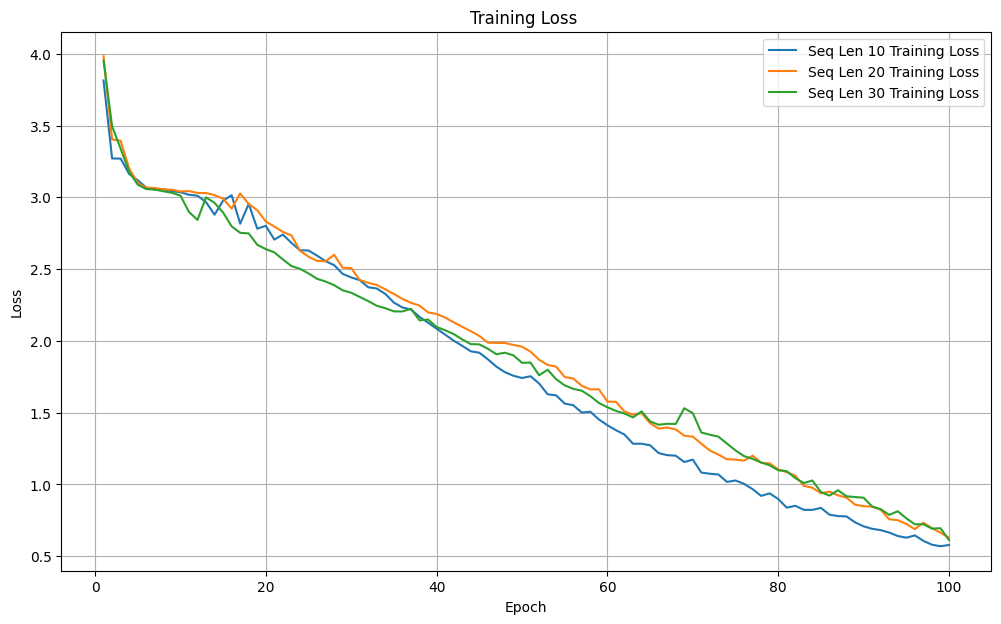

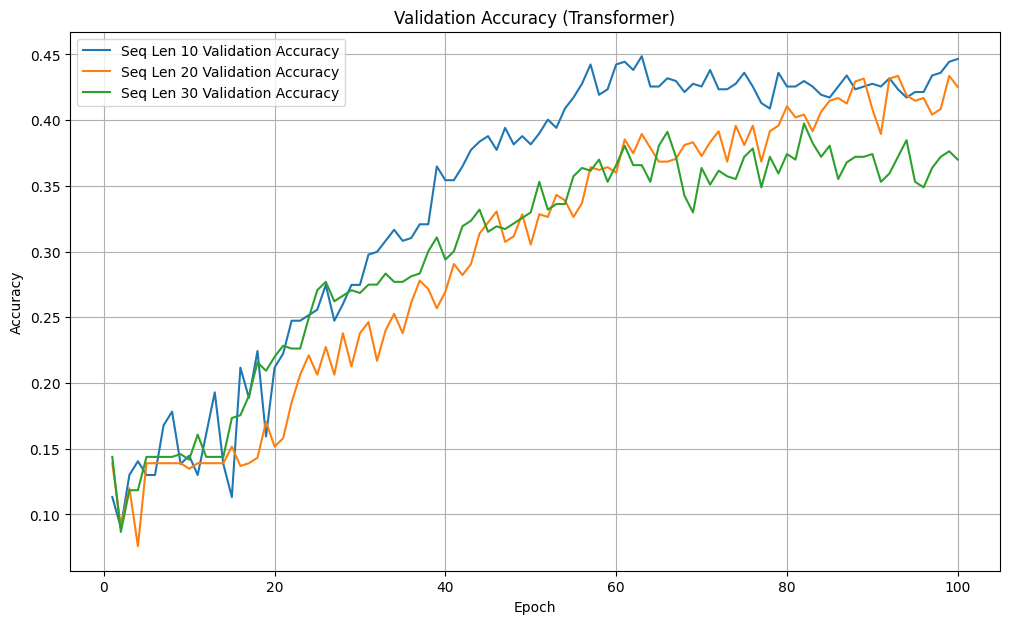

In [ ]:
import matplotlib.pyplot as plt

# Plotting Training Loss for each sequence length
plt.figure(figsize=(12, 7))
for index, row in df_transformer.iterrows():
    seq_len = row['seq_len']
    train_losses = row['train_losses_history']
    epochs_range = range(1, len(train_losses) + 1)
    plt.plot(epochs_range, train_losses, label=f'Seq Len {seq_len} Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss ')
plt.legend()
plt.grid(True)
plt.show()

# Plotting Validation Accuracy for each sequence length
plt.figure(figsize=(12, 7))
for index, row in df_transformer.iterrows():
    seq_len = row['seq_len']
    val_accuracies = row['val_accuracies_history']
    epochs_range = range(1, len(val_accuracies) + 1)
    plt.plot(epochs_range, val_accuracies, label=f'Seq Len {seq_len} Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy (Transformer)')
plt.legend()
plt.grid(True)
plt.show()

# **Problem 2: Transformer for Character Prediction on Tiny Shakespeare**

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
import requests

In [ ]:
# Step 1: Download the dataset
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
response = requests.get(url)
text = response.text  # This is the entire text data



In [ ]:
# Step 2: Prepare the dataset
sequence_length = 20
# Create a character mapping to integers
chars = sorted(list(set(text)))
char_to_int = {ch: i for i, ch in enumerate(chars)}
int_to_char = {i: ch for i, ch in enumerate(chars)}

# Encode the text into integers
encoded_text = [char_to_int[ch] for ch in text]

In [ ]:
# Create sequences and targets
sequences = []
targets = []
for i in range(0, len(encoded_text) - sequence_length):
    seq = encoded_text[i:i+sequence_length]
    target = encoded_text[i+sequence_length]
    sequences.append(seq)
    targets.append(target)

# Convert lists to PyTorch tensors
sequences = torch.tensor(sequences, dtype=torch.long)
targets = torch.tensor(targets, dtype=torch.long)

# Step 3: Create a dataset class
class CharDataset(Dataset):
    def __init__(self, sequences, targets):
        self.sequences = sequences
        self.targets = targets

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, index):
        return self.sequences[index], self.targets[index]

# Instantiate the dataset
dataset = CharDataset(sequences, targets)

# Step 4: Create data loaders
batch_size = 128
train_size = int(len(dataset) * 0.8)
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, shuffle=True, batch_size=batch_size)
test_loader = DataLoader(test_dataset, shuffle=False, batch_size=batch_size)

# **Transformer Model seqence length: 20**

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() *
                             (-np.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)   # shape: (1, max_len, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

In [ ]:
class CharTransformer(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers, nhead):
        super(CharTransformer, self).__init__()

        self.embedding = nn.Embedding(input_size, hidden_size)
        self.pos_encoder = PositionalEncoding(hidden_size)

        encoder_layers = nn.TransformerEncoderLayer(
            d_model=hidden_size,
            nhead=nhead,
            batch_first=True
        )

        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layers,
            num_layers=num_layers
        )

        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        embedded = self.embedding(x)
        embedded = self.pos_encoder(embedded)
        transformer_output = self.transformer_encoder(embedded)
        output = self.fc(transformer_output[:, -1, :])
        return output

In [ ]:
hidden_size = 128
num_layers = 2
nhead = 2
learning_rate = 0.001
epochs = 10

In [ ]:
# Model, loss, and optimizer
model = CharTransformer(len(chars), hidden_size, len(chars), num_layers, nhead)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)


In [ ]:
start_time = time.time()

train_losses = []
val_losses = []
val_accuracies = []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

for epoch in range(epochs):
    model.train()
    total_train_loss = 0

    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        output = model(inputs)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    train_losses.append(total_train_loss / len(train_loader))

    model.eval()
    total_val_loss = 0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            val_output = model(inputs)
            val_loss = criterion(val_output, labels)

            total_val_loss += val_loss.item()
            _, predicted = torch.max(val_output, 1)

            total_samples += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()

    val_losses.append(total_val_loss / len(test_loader))
    val_accuracy = correct_predictions / total_samples
    val_accuracies.append(val_accuracy)

    print(
        f'Epoch {epoch+1}, '
        f'Loss: {train_losses[-1]:.4f}, '
        f'Validation Loss: {val_losses[-1]:.4f}, '
        f'Validation Accuracy: {val_accuracies[-1]:.4f}'
    )

training_time = time.time() - start_time

# Final evaluation for summary metrics
model.eval()
with torch.no_grad():
    inference_start_time = time.time()

    # Get a sample input for inference speed and FLOPs calculation
    sample_inputs = None
    if len(test_loader) > 0:
        sample_inputs, _ = next(iter(test_loader))
        sample_inputs = sample_inputs.to(device)
    else:

        sample_inputs = torch.zeros(1, sequence_length, dtype=torch.long, device=device)

    # Run inference to measure speed
    model(sample_inputs)
    inference_end_time = time.time()
    inference_speed_ms_per_batch = (inference_end_time - inference_start_time) * 1000


    profile_input = sample_inputs[0].unsqueeze(0) if sample_inputs.ndim == 2 else sample_inputs
    flops, params_thop = profile(model, inputs=(profile_input,), verbose=False)
    avg_flops_per_validation_sample = flops

    val_loss_final = val_losses[-1] # Final average validation loss
    val_accuracy_final = val_accuracies[-1] # Final validation accuracy

# Calculate total parameters and model size
parameter_count = count_params(model)
model_size = model_size_mb(model)

# Prepare the results dictionary
problem2_single_run_results = {
    "model": "Transformer Problem 2 (Single Run)",
    "seq_len": sequence_length, # Fixed for Problem 2 setup
    "train_loss": round(train_losses[-1], 4),
    "val_acc": round(val_accuracies[-1], 4),
    "perplexity": round(perplexity(val_loss_final), 3),
    "params": parameter_count,
    "size_MB": round(model_size, 3),
    "train_time_s": round(training_time, 2),
    "inference_speed_ms_per_batch": round(inference_speed_ms_per_batch, 3),
    "avg_flops_per_validation_sample": round(avg_flops_per_validation_sample, 2),
    "train_losses_history": train_losses,
    "val_accuracies_history": val_accuracies
}

print("\n--- Problem 2 Training Results ---")
display(problem2_single_run_results)



Epoch 1, Loss: 1.9898, Validation Loss: 1.7130, Validation Accuracy: 0.4827
Epoch 2, Loss: 1.7520, Validation Loss: 1.6153, Validation Accuracy: 0.5106
Epoch 3, Loss: 1.6756, Validation Loss: 1.5639, Validation Accuracy: 0.5233
Epoch 4, Loss: 1.6306, Validation Loss: 1.5476, Validation Accuracy: 0.5266
Epoch 5, Loss: 1.5993, Validation Loss: 1.5153, Validation Accuracy: 0.5343
Epoch 6, Loss: 1.5754, Validation Loss: 1.4938, Validation Accuracy: 0.5405
Epoch 7, Loss: 1.5573, Validation Loss: 1.4741, Validation Accuracy: 0.5461
Epoch 8, Loss: 1.5411, Validation Loss: 1.4660, Validation Accuracy: 0.5478
Epoch 9, Loss: 1.5308, Validation Loss: 1.4614, Validation Accuracy: 0.5485
Epoch 10, Loss: 1.5188, Validation Loss: 1.4491, Validation Accuracy: 0.5532

--- Problem 2 Training Results ---


{'model': 'Transformer Problem 2 (Single Run)',
 'seq_len': 20,
 'train_loss': 1.5188,
 'val_acc': 0.5532,
 'perplexity': np.float64(4.259),
 'params': 1202753,
 'size_MB': 7.03,
 'train_time_s': 508.19,
 'inference_speed_ms_per_batch': 1.972,
 'avg_flops_per_validation_sample': 21020800.0,
 'train_losses_history': [1.9897950115692185,
  1.751990016752868,
  1.6756466117249913,
  1.630595336152573,
  1.5992680357163211,
  1.575408821065263,
  1.557339298625958,
  1.5411332993930056,
  1.5307993777374118,
  1.5188015804199124],
 'val_accuracies_history': [0.48272554073742013,
  0.5106354365123837,
  0.5233486495573237,
  0.5265941947775412,
  0.5343359856550487,
  0.540540177070492,
  0.5460540177070492,
  0.5477933430460608,
  0.5485240390003362,
  0.5531547685755912]}

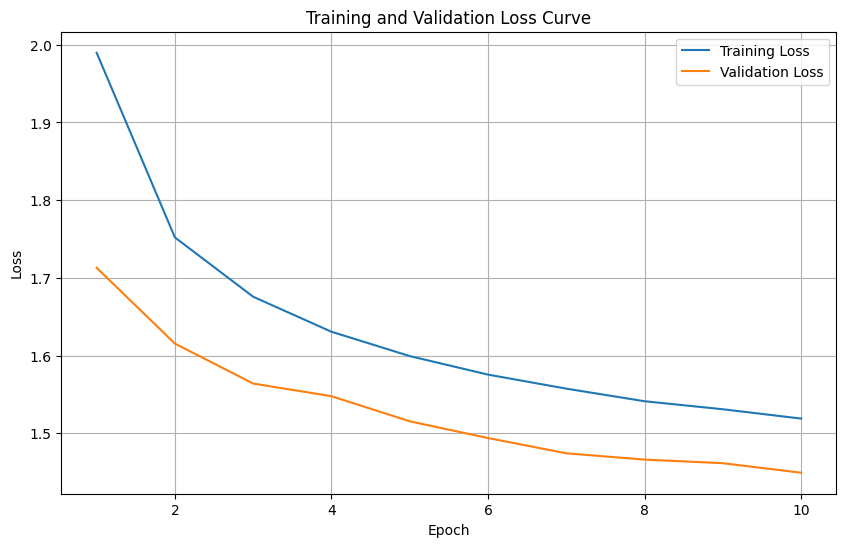

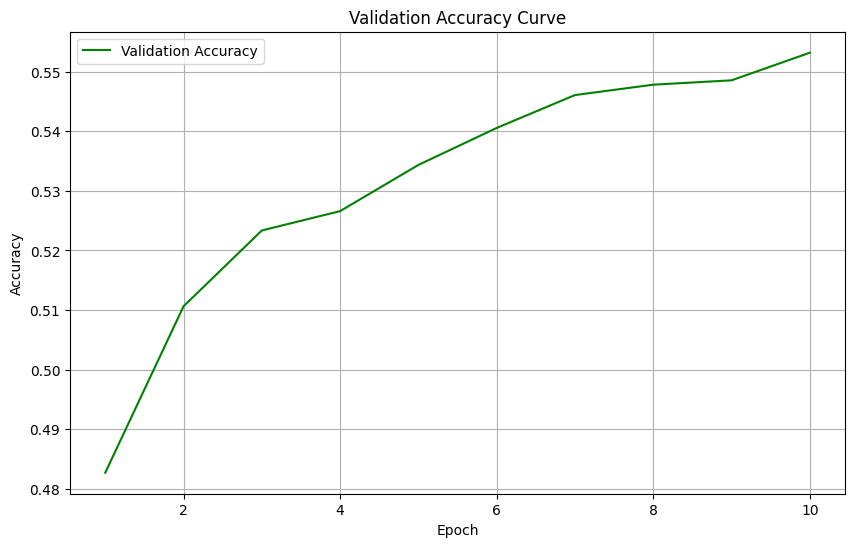

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss')
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Curve')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), val_accuracies, label='Validation Accuracy', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy Curve')
plt.legend()
plt.grid(True)
plt.show()

# **Transformer Model seqence length: 30**

In [ ]:

sequence_length = 30

chars = sorted(list(set(text)))
char_to_int = {ch: i for i, ch in enumerate(chars)}
int_to_char = {i: ch for i, ch in enumerate(chars)}


encoded_text = [char_to_int[ch] for ch in text]

In [ ]:

sequences = []
targets = []
for i in range(0, len(encoded_text) - sequence_length):
    seq = encoded_text[i:i+sequence_length]
    target = encoded_text[i+sequence_length]
    sequences.append(seq)
    targets.append(target)

sequences = torch.tensor(sequences, dtype=torch.long)
targets = torch.tensor(targets, dtype=torch.long)

class CharDataset(Dataset):
    def __init__(self, sequences, targets):
        self.sequences = sequences
        self.targets = targets

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, index):
        return self.sequences[index], self.targets[index]

dataset = CharDataset(sequences, targets)


batch_size = 128
train_size = int(len(dataset) * 0.8)
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, shuffle=True, batch_size=batch_size)
test_loader = DataLoader(test_dataset, shuffle=False, batch_size=batch_size)

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() *
                             (-np.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

In [ ]:
class CharTransformer(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers, nhead):
        super(CharTransformer, self).__init__()

        self.embedding = nn.Embedding(input_size, hidden_size)
        self.pos_encoder = PositionalEncoding(hidden_size)

        encoder_layers = nn.TransformerEncoderLayer(
            d_model=hidden_size,
            nhead=nhead,
            batch_first=True
        )

        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layers,
            num_layers=num_layers
        )

        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        embedded = self.embedding(x)
        embedded = self.pos_encoder(embedded)
        transformer_output = self.transformer_encoder(embedded)
        output = self.fc(transformer_output[:, -1, :])
        return output

In [ ]:
hidden_size = 128
num_layers = 2
nhead = 2
learning_rate = 0.001
epochs = 10

In [ ]:
# Model, loss, and optimizer
model = CharTransformer(len(chars), hidden_size, len(chars), num_layers, nhead)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)


In [ ]:
start_time = time.time()

train_losses = []
val_losses = []
val_accuracies = []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

for epoch in range(epochs):
    model.train()
    total_train_loss = 0

    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        output = model(inputs)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    train_losses.append(total_train_loss / len(train_loader))

    model.eval()
    total_val_loss = 0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            val_output = model(inputs)
            val_loss = criterion(val_output, labels)

            total_val_loss += val_loss.item()
            _, predicted = torch.max(val_output, 1)

            total_samples += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()

    val_losses.append(total_val_loss / len(test_loader))
    val_accuracy = correct_predictions / total_samples
    val_accuracies.append(val_accuracy)

    print(
        f'Epoch {epoch+1}, '
        f'Loss: {train_losses[-1]:.4f}, '
        f'Validation Loss: {val_losses[-1]:.4f}, '
        f'Validation Accuracy: {val_accuracies[-1]:.4f}'
    )

training_time = time.time() - start_time

# Final evaluation for summary metrics
model.eval()
with torch.no_grad():
    inference_start_time = time.time()

    # Get a sample input for inference speed and FLOPs calculation
    sample_inputs = None
    if len(test_loader) > 0:
        sample_inputs, _ = next(iter(test_loader))
        sample_inputs = sample_inputs.to(device)
    else:
        # Create a dummy input if test_loader is empty to prevent errors
        sample_inputs = torch.zeros(1, sequence_length, dtype=torch.long, device=device)

    # Run inference to measure speed
    model(sample_inputs)
    inference_end_time = time.time()
    inference_speed_ms_per_batch = (inference_end_time - inference_start_time) * 1000

    # For FLOPs calculation, profile with a single input sample
    # Ensure input to profile is a single sample, not a batch
    profile_input = sample_inputs[0].unsqueeze(0) if sample_inputs.ndim == 2 else sample_inputs
    flops, params_thop = profile(model, inputs=(profile_input,), verbose=False)
    avg_flops_per_validation_sample = flops

    val_loss_final = val_losses[-1] # Final average validation loss
    val_accuracy_final = val_accuracies[-1] # Final validation accuracy

# Calculate total parameters and model size
parameter_count = count_params(model)
model_size = model_size_mb(model)

# Prepare the results dictionary
problem2_single_run_results = {
    "model": "Transformer Problem 2 (Single Run)",
    "seq_len": sequence_length, # Fixed for Problem 2 setup
    "train_loss": round(train_losses[-1], 4),
    "val_acc": round(val_accuracies[-1], 4),
    "perplexity": round(perplexity(val_loss_final), 3),
    "params": parameter_count,
    "size_MB": round(model_size, 3),
    "train_time_s": round(training_time, 2),
    "inference_speed_ms_per_batch": round(inference_speed_ms_per_batch, 3),
    "avg_flops_per_validation_sample": round(avg_flops_per_validation_sample, 2),
    "train_losses_history": train_losses,
    "val_accuracies_history": val_accuracies
}

print("\n--- Problem 2 Training Results ---")
display(problem2_single_run_results)

# You can also display these as a DataFrame if preferred
# df_problem2_single_run = pd.DataFrame([problem2_single_run_results])
# display(df_problem2_single_run)

Epoch 1, Loss: 1.9943, Validation Loss: 1.7318, Validation Accuracy: 0.4791
Epoch 2, Loss: 1.7572, Validation Loss: 1.6331, Validation Accuracy: 0.5062
Epoch 3, Loss: 1.6806, Validation Loss: 1.5813, Validation Accuracy: 0.5157
Epoch 4, Loss: 1.6334, Validation Loss: 1.5443, Validation Accuracy: 0.5281
Epoch 5, Loss: 1.6002, Validation Loss: 1.5211, Validation Accuracy: 0.5360
Epoch 6, Loss: 1.5744, Validation Loss: 1.5037, Validation Accuracy: 0.5400
Epoch 7, Loss: 1.5565, Validation Loss: 1.4864, Validation Accuracy: 0.5427
Epoch 8, Loss: 1.5398, Validation Loss: 1.4726, Validation Accuracy: 0.5472
Epoch 9, Loss: 1.5269, Validation Loss: 1.4637, Validation Accuracy: 0.5501
Epoch 10, Loss: 1.5152, Validation Loss: 1.4543, Validation Accuracy: 0.5523

--- Problem 2 Training Results ---


{'model': 'Transformer Problem 2 (Single Run)',
 'seq_len': 30,
 'train_loss': 1.5152,
 'val_acc': 0.5523,
 'perplexity': np.float64(4.282),
 'params': 1202753,
 'size_MB': 7.03,
 'train_time_s': 529.44,
 'inference_speed_ms_per_batch': 1.986,
 'avg_flops_per_validation_sample': 31527040.0,
 'train_losses_history': [1.994258282363107,
  1.7572481465438832,
  1.6806487954695608,
  1.633446204340875,
  1.6002299750151088,
  1.57444595483549,
  1.5565481455040198,
  1.5398413104721684,
  1.5268727866179357,
  1.5152495946613318],
 'val_accuracies_history': [0.4791032531951424,
  0.5061706257592806,
  0.5157190695422574,
  0.5280872180855595,
  0.5360263232215463,
  0.5399532888337002,
  0.5427416137318277,
  0.5471616914642292,
  0.5501024328358878,
  0.5523483344017429]}

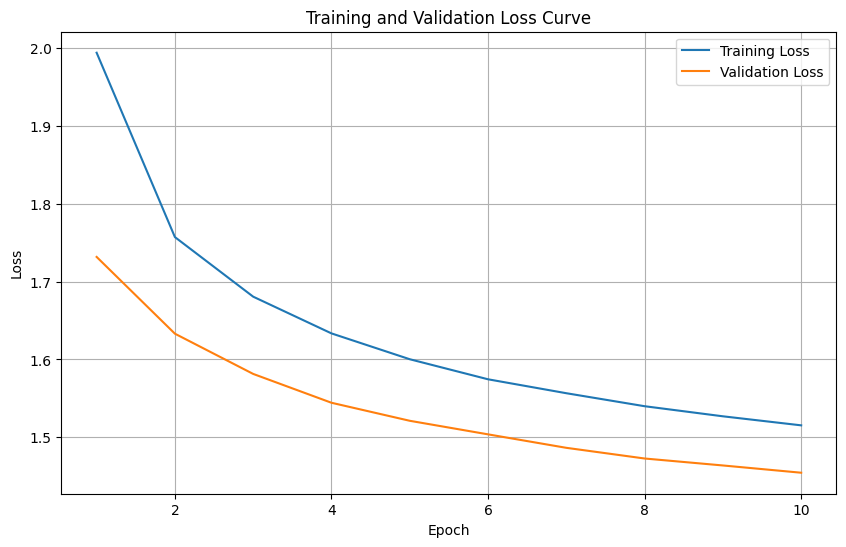

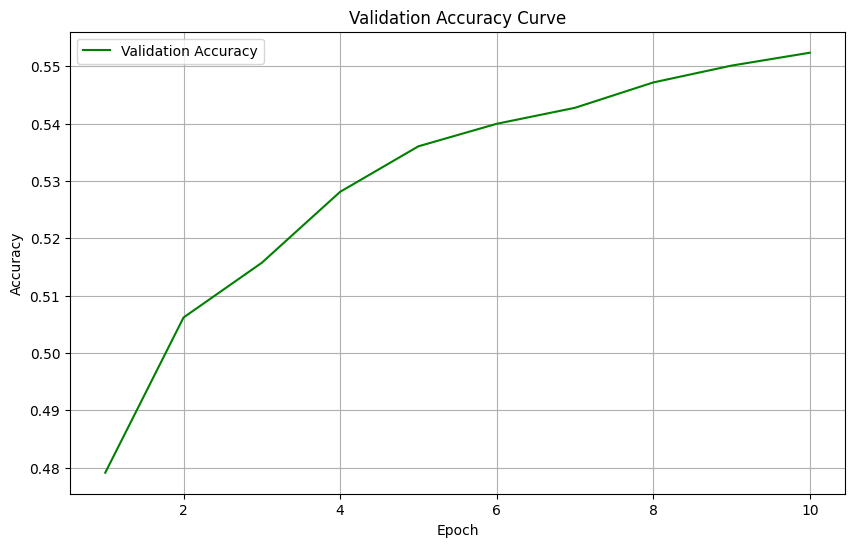

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss')
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Curve')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), val_accuracies, label='Validation Accuracy', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy Curve')
plt.legend()
plt.grid(True)
plt.show()

# **Part 2 - Adjust the hyperparameters**

In [ ]:

sequence_length = 20

chars = sorted(list(set(text)))
char_to_int = {ch: i for i, ch in enumerate(chars)}
int_to_char = {i: ch for i, ch in enumerate(chars)}


encoded_text = [char_to_int[ch] for ch in text]

In [ ]:

sequences = []
targets = []
for i in range(0, len(encoded_text) - sequence_length):
    seq = encoded_text[i:i+sequence_length]
    target = encoded_text[i+sequence_length]
    sequences.append(seq)
    targets.append(target)


sequences = torch.tensor(sequences, dtype=torch.long)
targets = torch.tensor(targets, dtype=torch.long)


class CharDataset(Dataset):
    def __init__(self, sequences, targets):
        self.sequences = sequences
        self.targets = targets

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, index):
        return self.sequences[index], self.targets[index]


dataset = CharDataset(sequences, targets)


batch_size = 128
train_size = int(len(dataset) * 0.8)
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, shuffle=True, batch_size=batch_size)
test_loader = DataLoader(test_dataset, shuffle=False, batch_size=batch_size)

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() *
                             (-np.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

In [ ]:
class CharTransformer(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers, nhead):
        super(CharTransformer, self).__init__()

        self.embedding = nn.Embedding(input_size, hidden_size)
        self.pos_encoder = PositionalEncoding(hidden_size)

        encoder_layers = nn.TransformerEncoderLayer(
            d_model=hidden_size,
            nhead=nhead,
            batch_first=True
        )

        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layers,
            num_layers=num_layers
        )

        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        embedded = self.embedding(x)
        embedded = self.pos_encoder(embedded)
        transformer_output = self.transformer_encoder(embedded)
        output = self.fc(transformer_output[:, -1, :])
        return output

In [ ]:
def train_transformer_combinations(seq_len, hidden_size, epochs, lr, num_layers, nhead, batch_size):

    sequences_p2 = []
    targets_p2 = []
    for i in range(0, len(encoded_text) - seq_len):
        seq = encoded_text[i:i+seq_len]
        target = encoded_text[i+seq_len]
        sequences_p2.append(seq)
        targets_p2.append(target)

    sequences_p2 = torch.tensor(sequences_p2, dtype=torch.long)
    targets_p2 = torch.tensor(targets_p2, dtype=torch.long)

    dataset_p2 = CharDataset(sequences_p2, targets_p2)

    train_size_p2 = int(len(dataset_p2) * 0.8)
    test_size_p2 = len(dataset_p2) - train_size_p2
    train_dataset_p2, test_dataset_p2 = torch.utils.data.random_split(dataset_p2, [train_size_p2, test_size_p2])

    train_loader_p2 = DataLoader(train_dataset_p2, shuffle=True, batch_size=batch_size)
    test_loader_p2 = DataLoader(test_dataset_p2, shuffle=False, batch_size=batch_size)

    model_p2 = CharTransformer(len(chars), hidden_size, len(chars), num_layers, nhead)
    criterion_p2 = nn.CrossEntropyLoss()
    optimizer_p2 = optim.Adam(model_p2.parameters(), lr=lr)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model_p2.to(device)

    train_losses_history = []
    val_accuracies_history = []

    start_time = time.time()

    for epoch in range(epochs):
        model_p2.train()
        total_train_loss = 0
        for inputs, labels in train_loader_p2:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer_p2.zero_grad()
            output = model_p2(inputs)
            loss = criterion_p2(output, labels)
            loss.backward()
            optimizer_p2.step()

            total_train_loss += loss.item()
        train_losses_history.append(total_train_loss / len(train_loader_p2))

        model_p2.eval()
        correct_predictions = 0
        total_samples = 0
        total_val_loss = 0
        with torch.no_grad():
            for inputs, labels in test_loader_p2:
                inputs = inputs.to(device)
                labels = labels.to(device)
                val_output = model_p2(inputs)
                val_loss = criterion_p2(val_output, labels)
                total_val_loss += val_loss.item()

                _, predicted = torch.max(val_output, 1)
                total_samples += labels.size(0)
                correct_predictions += (predicted == labels).sum().item()
        val_accuracies_history.append(correct_predictions / total_samples)

    train_time = time.time() - start_time


    model_p2.eval()
    with torch.no_grad():
        inference_start_time = time.time()

        sample_inputs, _ = next(iter(test_loader_p2))
        sample_inputs = sample_inputs.to(device)
        val_output_final = model_p2(sample_inputs)
        inference_end_time = time.time()
        inference_speed_ms_per_batch = (inference_end_time - inference_start_time) * 1000


        flops, params_thop = profile(model_p2, inputs=(sample_inputs[0].unsqueeze(0),), verbose=False)
        avg_flops_per_validation_sample = flops

        val_loss_final = total_val_loss / len(test_loader_p2)
        val_accuracy_final = val_accuracies_history[-1]


    def generate_text(model, start_string, num_generate=50, temperature=1.0):
        model.eval()
        input_eval = [char_to_int[s] for s in start_string]
        input_eval = torch.tensor(input_eval, dtype=torch.long).unsqueeze(0).to(device)

        text_generated = []
        model.eval()
        with torch.no_grad():
            for i in range(num_generate):
                predictions = model(input_eval)
                predictions = predictions.squeeze(0) / temperature
                predicted_id = torch.multinomial(torch.softmax(predictions, dim=0), 1).item()

                input_eval = torch.cat([input_eval[:, 1:], torch.tensor([[predicted_id]], dtype=torch.long).to(device)], dim=1)
                text_generated.append(int_to_char[predicted_id])

        return start_string + ''.join(text_generated)

    start_prompt = "The quick brown fox jumps over the lazy dog."
    if len(start_prompt) < seq_len:
        start_prompt = start_prompt.ljust(seq_len, ' ')
    else:
        start_prompt = start_prompt[:seq_len]

    generated_text = generate_text(model_p2, start_prompt, num_generate=50)
    print(f"\nGenerated Output Sequence: {generated_text}")

    return {
        "model": "Transformer Problem 2",
        "seq_len": seq_len,
        "train_loss": round(train_losses_history[-1], 4),
        "val_acc": round(val_accuracies_history[-1], 4),
        "perplexity": round(perplexity(val_loss_final), 3),
        "params": count_params(model_p2),
        "size_MB": round(model_size_mb(model_p2), 3),
        "train_time_s": round(train_time, 2),
        "inference_speed_ms_per_batch": round(inference_speed_ms_per_batch, 3),
        "avg_flops_per_validation_sample": round(avg_flops_per_validation_sample, 2),
        "train_losses_history": train_losses_history,
        "val_accuracies_history": val_accuracies_history,
        "generated_output": generated_text
    }

In [ ]:
hidden_size = 128
learning_rate = 0.001
epochs = 10

In [ ]:
# Model, loss, and optimizer
model = CharTransformer(len(chars), hidden_size, len(chars), num_layers, nhead)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)


In [ ]:
num_layers_list = [1, 2, 4]
nhead_list = [2, 4]

hyperparam_results = []



for current_num_layers in num_layers_list:
    for current_nhead in nhead_list:
        print(f"\nTraining Transformer: num_layers={current_num_layers}, nhead={current_nhead}")


        result = train_transformer_combinations(
            seq_len=sequence_length,
            hidden_size=hidden_size,
            epochs=epochs,
            lr=learning_rate,
            num_layers=current_num_layers,
            nhead=current_nhead,
            batch_size=batch_size
        )

        result["num_layers"] = current_num_layers
        result["nhead"] = current_nhead
        hyperparam_results.append(result)

df_hyperparams = pd.DataFrame(hyperparam_results)
display(df_hyperparams)


Training Transformer: num_layers=1, nhead=2

Training Transformer: num_layers=1, nhead=4

Training Transformer: num_layers=2, nhead=2

Training Transformer: num_layers=2, nhead=4

Training Transformer: num_layers=4, nhead=2

Training Transformer: num_layers=4, nhead=4


,model,seq_len,train_loss,val_acc,perplexity,params,size_MB,train_time_s,inference_speed_ms_per_batch,avg_flops_per_validation_sample,train_losses_history,val_accuracies_history,num_layers,nhead
0,Transformer Problem 2,30,1.6513,0.5298,4.628,609729,4.767,356.66,1.385,15767680.0,"[2.065087259841663, 1.8669397908760361, 1.8065...","[0.4594818736467434, 0.48179295566922037, 0.49...",1,2
1,Transformer Problem 2,30,1.6084,0.5369,4.521,609729,4.767,355.88,1.340,15767680.0,"[2.0197361442663855, 1.7985552214064684, 1.735...","[0.47760598548457234, 0.49994396453179, 0.5126...",1,4
2,Transformer Problem 2,30,1.5148,0.5539,4.247,1202753,7.030,530.21,1.705,31527040.0,"[1.997674392939161, 1.7562022637308703, 1.6790...","[0.48162260784586214, 0.5052695754304645, 0.51...",2,2
3,Transformer Problem 2,30,1.5000,0.5550,4.206,1202753,7.030,530.11,1.681,31527040.0,"[1.981538698205439, 1.733170740661167, 1.65993...","[0.49056138573471464, 0.5142038704818602, 0.52...",2,4
4,Transformer Problem 2,30,1.4903,0.5534,4.269,2388801,11.554,878.52,2.267,63045760.0,"[2.043199729163689, 1.7568262232936667, 1.6760...","[0.47112828535950113, 0.5012305388818907, 0.51...",4,2
5,Transformer Problem 2,30,1.4881,0.5573,4.209,2388801,11.554,879.61,2.286,63045760.0,"[2.015709081157076, 1.7384125426522767, 1.6583...","[0.4797218847641803, 0.5059554495613544, 0.519...",4,4


# **Part 3 - Seqence length of 50**

In [ ]:

sequence_length = 50

chars = sorted(list(set(text)))
char_to_int = {ch: i for i, ch in enumerate(chars)}
int_to_char = {i: ch for i, ch in enumerate(chars)}


encoded_text = [char_to_int[ch] for ch in text]

In [ ]:

sequences = []
targets = []
for i in range(0, len(encoded_text) - sequence_length):
    seq = encoded_text[i:i+sequence_length]
    target = encoded_text[i+sequence_length]
    sequences.append(seq)
    targets.append(target)

# Convert lists to PyTorch tensors
sequences = torch.tensor(sequences, dtype=torch.long)
targets = torch.tensor(targets, dtype=torch.long)


class CharDataset(Dataset):
    def __init__(self, sequences, targets):
        self.sequences = sequences
        self.targets = targets

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, index):
        return self.sequences[index], self.targets[index]


dataset = CharDataset(sequences, targets)


batch_size = 128
train_size = int(len(dataset) * 0.8)
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, shuffle=True, batch_size=batch_size)
test_loader = DataLoader(test_dataset, shuffle=False, batch_size=batch_size)

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() *
                             (-np.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

In [ ]:
class CharTransformer(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers, nhead):
        super(CharTransformer, self).__init__()

        self.embedding = nn.Embedding(input_size, hidden_size)
        self.pos_encoder = PositionalEncoding(hidden_size)

        encoder_layers = nn.TransformerEncoderLayer(
            d_model=hidden_size,
            nhead=nhead,
            batch_first=True
        )

        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layers,
            num_layers=num_layers
        )

        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        embedded = self.embedding(x)
        embedded = self.pos_encoder(embedded)
        transformer_output = self.transformer_encoder(embedded)
        output = self.fc(transformer_output[:, -1, :])
        return output

In [ ]:
hidden_size = 128
num_layers = 2
nhead = 2
learning_rate = 0.001
epochs = 10

In [ ]:
# Model, loss, and optimizer
model = CharTransformer(len(chars), hidden_size, len(chars), num_layers, nhead)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)


In [ ]:
start_time = time.time()

train_losses = []
val_losses = []
val_accuracies = []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

for epoch in range(epochs):
    model.train()
    total_train_loss = 0

    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        output = model(inputs)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    train_losses.append(total_train_loss / len(train_loader))

    model.eval()
    total_val_loss = 0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            val_output = model(inputs)
            val_loss = criterion(val_output, labels)

            total_val_loss += val_loss.item()
            _, predicted = torch.max(val_output, 1)

            total_samples += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()

    val_losses.append(total_val_loss / len(test_loader))
    val_accuracy = correct_predictions / total_samples
    val_accuracies.append(val_accuracy)

    print(
        f'Epoch {epoch+1}, '
        f'Loss: {train_losses[-1]:.4f}, '
        f'Validation Loss: {val_losses[-1]:.4f}, '
        f'Validation Accuracy: {val_accuracies[-1]:.4f}'
    )

training_time = time.time() - start_time

# Final evaluation for summary metrics
model.eval()
with torch.no_grad():
    inference_start_time = time.time()


    sample_inputs = None
    if len(test_loader) > 0:
        sample_inputs, _ = next(iter(test_loader))
        sample_inputs = sample_inputs.to(device)
    else:

        sample_inputs = torch.zeros(1, sequence_length, dtype=torch.long, device=device)


    model(sample_inputs)
    inference_end_time = time.time()
    inference_speed_ms_per_batch = (inference_end_time - inference_start_time) * 1000


    profile_input = sample_inputs[0].unsqueeze(0) if sample_inputs.ndim == 2 else sample_inputs
    flops, params_thop = profile(model, inputs=(profile_input,), verbose=False)
    avg_flops_per_validation_sample = flops

    val_loss_final = val_losses[-1]
    val_accuracy_final = val_accuracies[-1]


parameter_count = count_params(model)
model_size = model_size_mb(model)

# Prepare the results dictionary
problem2_single_run_results = {
    "model": "Transformer Problem 2 (Single Run)",
    "seq_len": sequence_length,
    "train_loss": round(train_losses[-1], 4),
    "val_acc": round(val_accuracies[-1], 4),
    "perplexity": round(perplexity(val_loss_final), 3),
    "params": parameter_count,
    "size_MB": round(model_size, 3),
    "train_time_s": round(training_time, 2),
    "inference_speed_ms_per_batch": round(inference_speed_ms_per_batch, 3),
    "avg_flops_per_validation_sample": round(avg_flops_per_validation_sample, 2),
    "train_losses_history": train_losses,
    "val_accuracies_history": val_accuracies
}

print("\n--- Problem 2 Training Results ---")
display(problem2_single_run_results)



Epoch 1, Loss: 1.9901, Validation Loss: 1.6991, Validation Accuracy: 0.4875
Epoch 2, Loss: 1.7460, Validation Loss: 1.6095, Validation Accuracy: 0.5108
Epoch 3, Loss: 1.6706, Validation Loss: 1.5569, Validation Accuracy: 0.5262
Epoch 4, Loss: 1.6243, Validation Loss: 1.5233, Validation Accuracy: 0.5329
Epoch 5, Loss: 1.5901, Validation Loss: 1.4982, Validation Accuracy: 0.5408
Epoch 6, Loss: 1.5642, Validation Loss: 1.4814, Validation Accuracy: 0.5443
Epoch 7, Loss: 1.5457, Validation Loss: 1.4682, Validation Accuracy: 0.5470
Epoch 8, Loss: 1.5289, Validation Loss: 1.4567, Validation Accuracy: 0.5500
Epoch 9, Loss: 1.5151, Validation Loss: 1.4438, Validation Accuracy: 0.5541
Epoch 10, Loss: 1.5037, Validation Loss: 1.4332, Validation Accuracy: 0.5563

--- Problem 2 Training Results ---


{'model': 'Transformer Problem 2 (Single Run)',
 'seq_len': 50,
 'train_loss': 1.5037,
 'val_acc': 0.5563,
 'perplexity': np.float64(4.192),
 'params': 1202753,
 'size_MB': 7.03,
 'train_time_s': 541.66,
 'inference_speed_ms_per_batch': 1.981,
 'avg_flops_per_validation_sample': 52539520.0,
 'train_losses_history': [1.9901098311161178,
  1.7460141348849068,
  1.6706443127079582,
  1.62433036757822,
  1.5900525537834775,
  1.5641946194076484,
  1.5457270612950613,
  1.5288736408606027,
  1.5151202958619607,
  1.5037439307084368],
 'val_accuracies_history': [0.48749490068095525,
  0.5107612442786761,
  0.5261869645715003,
  0.5329382388408967,
  0.540783345063635,
  0.5442979526514218,
  0.54701460086341,
  0.5499643608031596,
  0.5541245085601316,
  0.5562718262062412]}

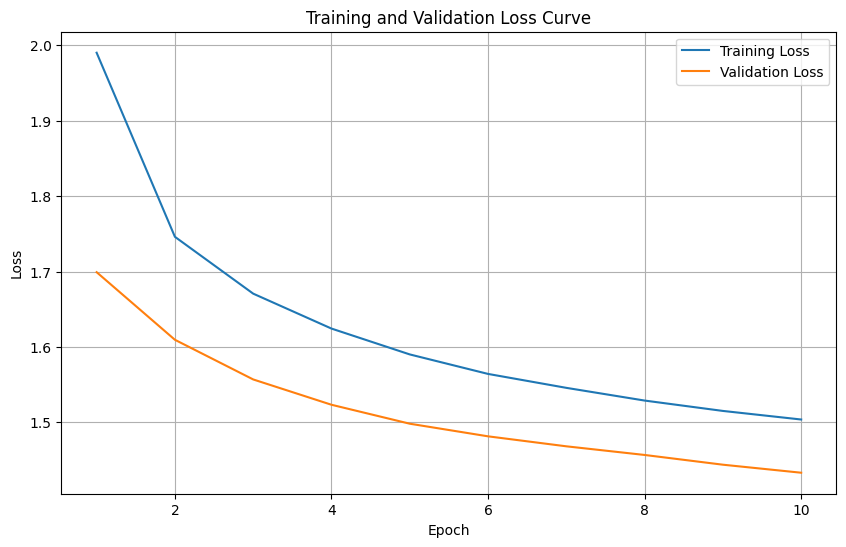

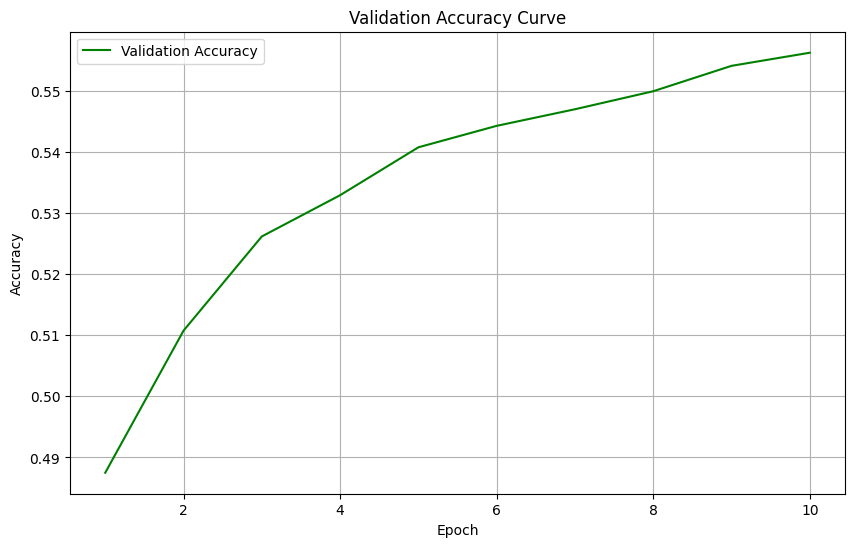

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss')
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Curve')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), val_accuracies, label='Validation Accuracy', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy Curve')
plt.legend()
plt.grid(True)
plt.show()

# **Transformer-Based Encoder-Decoder for English-to-French Translation**

In [ ]:
import sys
import subprocess


In [ ]:
# Automatically install nltk if it's missing to ensure error-free execution
try:
    import nltk
except ImportError:
    print("NLTK library not found. Installing it now...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "nltk"])
    import nltk


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import numpy as np
import random
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from sklearn.model_selection import train_test_split
import time
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import matplotlib.pyplot as plt




In [ ]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
#downloads dataset from google drive
dataset = pd.read_csv('/content/drive/MyDrive/vast_english_french.txt',
    sep='\t',
    header=None,
    names=['English', 'French']
)



In [ ]:
train_df, val_df = train_test_split(
    dataset,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

In [ ]:
PAD_token = 0
SOS_token = 1
EOS_token = 2
UNK_token = 3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
def split_word(sentence):
    return sentence.lower().strip().split()

In [ ]:
def build_vocab(sentences):
    vocab = {
        "PAD": PAD_token,
        "SOS": SOS_token,
        "EOS": EOS_token,
        "UNK": UNK_token
    }

    for sentence in sentences:
        for word in split_word(sentence):
            if word not in vocab:
                vocab[word] = len(vocab)

    return vocab

In [ ]:
english_to_index = build_vocab(train_df["English"])
french_to_index = build_vocab(train_df["French"])

index_to_english = {i: word for word, i in english_to_index.items()}
index_to_french = {i: word for word, i in french_to_index.items()}

In [ ]:
class TranslationDataset(Dataset):
    def __init__(self, dataframe, english_to_index, french_to_index):
        self.dataframe = dataframe.reset_index(drop=True)
        self.english_to_index = english_to_index
        self.french_to_index = french_to_index

    def __len__(self):
        return len(self.dataframe)

    def sentence_to_tensor(self, sentence, vocab):
      tokens = split_word(sentence)

      indexes = [SOS_token]

      indexes += [vocab.get(word, UNK_token) for word in tokens]

      indexes.append(EOS_token)

      return torch.tensor(indexes, dtype=torch.long, device=device)

    def __getitem__(self, idx):
        english_sentence = self.dataframe.iloc[idx]["English"]
        french_sentence = self.dataframe.iloc[idx]["French"]

        input_tensor = self.sentence_to_tensor(
            english_sentence,
            self.english_to_index,
            add_sos=True
        )

        target_tensor = self.sentence_to_tensor(
            french_sentence,
            self.french_to_index,
            add_sos=True
        )

        return input_tensor, target_tensor


In [ ]:
def collate_fn(batch):
    src_batch, tgt_batch = zip(*batch)

    src_batch = nn.utils.rnn.pad_sequence(
        src_batch,
        batch_first=True,
        padding_value=PAD_token
    )

    tgt_batch = nn.utils.rnn.pad_sequence(
        tgt_batch,
        batch_first=True,
        padding_value=PAD_token
    )

    return src_batch.to(device), tgt_batch.to(device)

In [ ]:

train_dataset = TranslationDataset(train_df, english_to_index, french_to_index)
val_dataset = TranslationDataset(val_df, english_to_index, french_to_index)


train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    collate_fn=collate_fn
)

In [ ]:
MAX_LENGTH = max(len(split_word(sentence)) for sentence in train_df["English"]) + 1

#Baseline Encoder-Decoder Architecture - Transformer

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() *
                             (-np.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)  # shape: (1, max_len, d_model)
        self.register_buffer("pe", pe)

    def forward(self, x):
        # x shape: (batch, seq_len, d_model)
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

In [ ]:
class TransformerSeq2Seq(nn.Module):
    def __init__(
        self,
        input_vocab_size,
        output_vocab_size,
        hidden_size,
        num_layers,
        nhead,
        pad_idx,
        dropout=0.3
    ):
        super().__init__()

        self.hidden_size = hidden_size
        self.pad_idx = pad_idx

        self.src_embedding = nn.Embedding(input_vocab_size, hidden_size)
        self.tgt_embedding = nn.Embedding(output_vocab_size, hidden_size)

        self.src_pos_encoder = PositionalEncoding(hidden_size, dropout)
        self.tgt_pos_encoder = PositionalEncoding(hidden_size, dropout)

        self.transformer = nn.Transformer(
            d_model=hidden_size,
            nhead=nhead,
            num_encoder_layers=num_layers,
            num_decoder_layers=num_layers,
            dim_feedforward=512,
            dropout=dropout,
            batch_first=True
        )

        self.fc_out = nn.Linear(hidden_size, output_vocab_size)

    def make_tgt_mask(self, tgt):
        tgt_len = tgt.size(1)

        mask = torch.triu(
            torch.ones(tgt_len, tgt_len, device=tgt.device),
            diagonal=1
        )

        mask = mask.masked_fill(mask == 1, float("-inf"))
        return mask

    def forward(self, src, tgt):
        src_key_padding_mask = src == self.pad_idx
        tgt_key_padding_mask = tgt == self.pad_idx
        tgt_mask = self.make_tgt_mask(tgt)

        src_emb = self.src_embedding(src) * math.sqrt(self.hidden_size)
        tgt_emb = self.tgt_embedding(tgt) * math.sqrt(self.hidden_size)

        src_emb = self.src_pos_encoder(src_emb)
        tgt_emb = self.tgt_pos_encoder(tgt_emb)

        output = self.transformer(
            src_emb,
            tgt_emb,
            tgt_mask=tgt_mask,
            src_key_padding_mask=src_key_padding_mask,
            tgt_key_padding_mask=tgt_key_padding_mask,
            memory_key_padding_mask=src_key_padding_mask
        )

        return self.fc_out(output)


In [ ]:
hidden_size = 128
num_layers = 2
nhead = 2
learning_rate = 0.001
epochs = 50

model = TransformerSeq2Seq(
    input_vocab_size=len(english_to_index),
    output_vocab_size=len(french_to_index),
    hidden_size=hidden_size,
    num_layers=num_layers,
    nhead=nhead,
    pad_idx=PAD_token
).to(device)

optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_token)


In [ ]:
import math
import copy

train_losses = []
val_losses = []

best_val_loss = float('inf')
best_model_state = None

print("Starting Training...")

for epoch in range(epochs):
    model.train()
    total_train_loss = 0

    for src, tgt in train_loader:


        optimizer.zero_grad()

        output = model(src, tgt[:, :-1])


        loss = criterion(output.reshape(-1, output.shape[-1]), tgt[:, 1:].reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for src, tgt in val_loader:

            output = model(src, tgt[:, :-1])
            loss = criterion(output.reshape(-1, output.shape[-1]), tgt[:, 1:].reshape(-1))
            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    # Checkpointing:
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_state = copy.deepcopy(model.state_dict())
        print(f"    (New best model saved at epoch {epoch+1} with validation loss: {best_val_loss:.4f})")

    if (epoch + 1) % 5 == 0:
        print(
            f"Epoch {epoch+1:02d} | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Val Loss: {avg_val_loss:.4f}"
        )

print("\nLoading best model checkpoint for evaluation...")
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"Best model (with validation loss: {best_val_loss:.4f}) loaded successfully.")
else:
    print("No best model found. Using the model from the last epoch.")

Starting Training...
    (New best model saved at epoch 1 with validation loss: 5.8880)
    (New best model saved at epoch 2 with validation loss: 5.8090)
    (New best model saved at epoch 3 with validation loss: 5.7168)
    (New best model saved at epoch 4 with validation loss: 5.5925)
    (New best model saved at epoch 5 with validation loss: 5.5035)
Epoch 05 | Train Loss: 5.1239 | Val Loss: 5.5035
    (New best model saved at epoch 6 with validation loss: 5.3964)
    (New best model saved at epoch 7 with validation loss: 5.2730)
    (New best model saved at epoch 8 with validation loss: 5.1603)
    (New best model saved at epoch 9 with validation loss: 5.0399)
    (New best model saved at epoch 10 with validation loss: 5.0106)
Epoch 10 | Train Loss: 4.4541 | Val Loss: 5.0106
    (New best model saved at epoch 11 with validation loss: 4.9082)
    (New best model saved at epoch 13 with validation loss: 4.8952)
    (New best model saved at epoch 14 with validation loss: 4.7319)
Epoch 

In [ ]:
def estimate_baseline_flops(input_tensor, target_tensor, hidden_size, output_vocab_size):
    input_len = input_tensor.size(0)
    target_len = target_tensor.size(0)

    # Encoder FLOPs
    encoder_flops = input_len * (12 * hidden_size * hidden_size)


    decoder_flops = target_len * (12 * hidden_size * hidden_size + hidden_size * output_vocab_size)

    return encoder_flops + decoder_flops

In [ ]:
def average_baseline_flops(val_loader, hidden_size, output_vocab_size):
    total_flops = 0
    total_samples = 0

    for input_tensor, target_tensor in val_loader:
        input_tensor = input_tensor[0]
        target_tensor = target_tensor[0]

        total_flops += estimate_baseline_flops(
            input_tensor,
            target_tensor,
            hidden_size,
            output_vocab_size
        )

        total_samples += 1

    return total_flops / total_samples

In [ ]:
baseline_params = count_parameters(model)
baseline_flops = average_baseline_flops(val_loader, hidden_size, len(french_to_index))

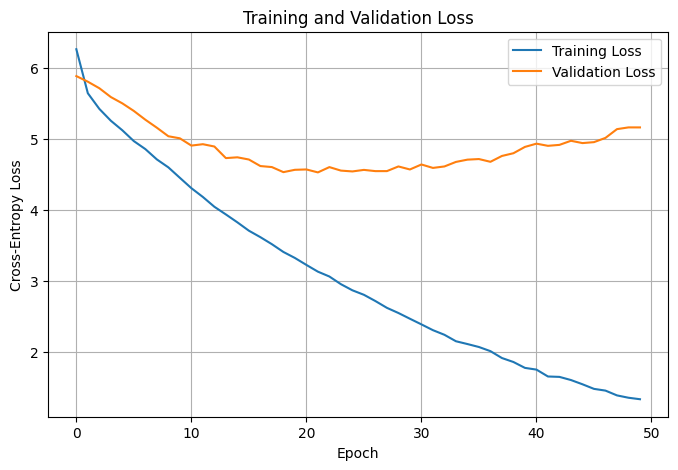

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
def greedy_decode(model, src, max_len, sos_idx, eos_idx, pad_idx, device):
    model.eval()
    with torch.no_grad():
        # Encode the source sequence
        src_padding_mask = (src == pad_idx).to(device)
        src_emb = model.src_embedding(src) * math.sqrt(model.hidden_size)
        src_emb = model.src_pos_encoder(src_emb)
        memory = model.transformer.encoder(src_emb, src_key_padding_mask=src_padding_mask)

        # Initialize target sequence with SOS token
        generated_tokens = [sos_idx]
        tgt_tensor = torch.tensor([sos_idx], dtype=torch.long, device=device).unsqueeze(0) # (1, 1)

        for i in range(max_len):
            tgt_mask = model.make_tgt_mask(tgt_tensor) # Look-ahead mask

            tgt_emb = model.tgt_embedding(tgt_tensor) * math.sqrt(model.hidden_size)
            tgt_emb = model.tgt_pos_encoder(tgt_emb)

            output = model.transformer.decoder(
                tgt_emb,
                memory,
                tgt_mask=tgt_mask,
                tgt_key_padding_mask=None, # No padding in growing target sequence during generation
                memory_key_padding_mask=src_padding_mask
            )

            # Take the last token's output for prediction
            next_token_logits = model.fc_out(output[:, -1, :]) # (1, output_vocab_size)
            next_token = next_token_logits.argmax(dim=-1).item()

            generated_tokens.append(next_token)

            if next_token == eos_idx:
                break

            # Append the predicted token to the target sequence for the next iteration
            tgt_tensor = torch.cat(
                [tgt_tensor, torch.tensor([[next_token]], dtype=torch.long, device=device)], dim=1
            )
        return generated_tokens[1:] # Exclude SOS token

In [ ]:
def evaluate_inference_speed_transformer(model, val_loader):
    model.eval()
    start_time = time.time()
    num_samples_processed = 0

    with torch.no_grad():
        for src, _ in val_loader:

            src_sample = src[0].unsqueeze(0)
            _ = greedy_decode(
                model,
                src_sample,
                max_len=MAX_LENGTH + 5,
                sos_idx=SOS_token,
                eos_idx=EOS_token,
                pad_idx=PAD_token,
                device=device
            )
            num_samples_processed += 1

    end_time = time.time()
    total_inference_time_ms = (end_time - start_time) * 1000
    if num_samples_processed > 0:
        infer_ms_per_sample = total_inference_time_ms / num_samples_processed
    else:
        infer_ms_per_sample = 0.0

    return infer_ms_per_sample

In [ ]:
baseline_infer_ms_per_sample = evaluate_inference_speed_transformer(model, val_loader)

print(f"Baseline Parameters: {baseline_params:,}")
print(f"Baseline Avg FLOPs per validation sample: {baseline_flops:,.0f}")
print(f"Baseline Inference Speed per sample (ms): {baseline_infer_ms_per_sample:.2f}")

Baseline Parameters: 1,295,841
Baseline Avg FLOPs per validation sample: 6,110,784
Baseline Inference Speed per sample (ms): 23.07


In [ ]:
def indexes_to_words(indexes, index_to_word):
    words = []

    for idx in indexes:
        if idx in [SOS_token, EOS_token, PAD_token]:
            continue
        words.append(index_to_word.get(idx, "UNK"))

    return words

In [ ]:
def evaluate_validation_metrics(model, val_loader, max_length=MAX_LENGTH + 5, n_examples=5):
    model.eval()
    correct_exact_matches = 0
    total_bleu_score = 0.0
    total_samples = 0

    smoothing = SmoothingFunction().method1

    print("\n--- Validation Examples ---")

    with torch.no_grad():
        for i, (input_tensor, target_tensor) in enumerate(val_loader):
            # Iterate through each sample in the batch
            for j in range(input_tensor.size(0)):
                src_sample = input_tensor[j].unsqueeze(0)  # (1, seq_len)
                tgt_sample = target_tensor[j]  # (seq_len)

                predicted_indices_list = greedy_decode(
                    model,
                    src_sample,
                    max_len=max_length,
                    sos_idx=SOS_token,
                    eos_idx=EOS_token,
                    pad_idx=PAD_token,
                    device=device
                )

                # Convert predicted indices to words, filtering special tokens
                input_indices = src_sample.squeeze(0).cpu().tolist()
                target_indices = tgt_sample.cpu().tolist()

                input_words = [
                    index_to_english.get(idx, "UNK")
                    for idx in input_indices
                    if idx not in [SOS_token, EOS_token, PAD_token]
                ]
                target_words = [
                    index_to_french.get(idx, "UNK")
                    for idx in target_indices
                    if idx not in [SOS_token, EOS_token, PAD_token]
                ]
                predicted_words = [
                    index_to_french.get(idx, "UNK")
                    for idx in predicted_indices_list
                    if idx not in [SOS_token, EOS_token, PAD_token]
                ]

                if predicted_words == target_words:
                    correct_exact_matches += 1

                # sentence_bleu expects a list of reference sentences and a candidate sentence
                # each sentence should be a list of tokens
                if len(target_words) > 0 and len(predicted_words) > 0:  # Avoid BLEU calculation for empty sentences
                    bleu = sentence_bleu(
                        [target_words],
                        predicted_words,
                        weights=(0.25, 0.25, 0.25, 0.25),
                        smoothing_function=smoothing
                    )
                else:
                    bleu = 0.0  # If either target or predicted is empty, BLEU is 0

                total_bleu_score += bleu
                total_samples += 1

                if total_samples <= n_examples:  # Display only n_examples
                    print(f"Input:     {' '.join(input_words)}")
                    print(f"Target:    {' '.join(target_words)}")
                    print(f"Predicted: {' '.join(predicted_words)}")
                    print(f"BLEU-4:    {bleu:.4f}")
                    print("-" * 60)

    exact_accuracy = correct_exact_matches / total_samples
    avg_bleu = total_bleu_score / total_samples

    print("\nFinal Validation Metrics:")
    print(f"Traditional Exact-Match Accuracy: {exact_accuracy * 100:.2f}%")
    print(f"Average Validation BLEU-4 Score: {avg_bleu:.4f}")

    return exact_accuracy, avg_bleu

In [ ]:
exact_accuracy, avg_bleu = evaluate_validation_metrics(
    model,
    val_loader
)


--- Validation Examples ---
Input:     she won a tennis match
Target:    elle a gagné un match de tennis
Predicted: elle a acheté un collier de la musique
BLEU-4:    0.0699
------------------------------------------------------------
Input:     the organic market opens at UNK on UNK
Target:    le marché biologique ouvre à UNK le UNK
Predicted: le pain est trop sucré
BLEU-4:    0.0295
------------------------------------------------------------
Input:     we watch a movie together
Target:    nous regardons un film ensemble
Predicted: nous avons traversé un voyage
BLEU-4:    0.0639
------------------------------------------------------------
Input:     the bread at this bakery is always UNK
Target:    le pain de cette boulangerie est toujours UNK
Predicted: le pain est trop est trop sucré
BLEU-4:    0.0670
------------------------------------------------------------
Input:     we dance at the wedding
Target:    nous UNK au mariage
Predicted: nous avons traversé le parc
BLEU-4:    0.0537

# **Problem** 4

In [ ]:
train_df, val_df = train_test_split(
    dataset,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

In [ ]:
PAD_token = 0
SOS_token = 1
EOS_token = 2
UNK_token = 3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
def split_word(sentence):
    return sentence.lower().strip().split()

In [ ]:
def build_vocab(sentences):
    vocab = {
        "PAD": PAD_token,
        "SOS": SOS_token,
        "EOS": EOS_token,
        "UNK": UNK_token
    }

    for sentence in sentences:
        for word in split_word(sentence):
            if word not in vocab:
                vocab[word] = len(vocab)

    return vocab

In [ ]:
french_to_index = build_vocab(train_df["French"])
english_to_index = build_vocab(train_df["English"])

index_to_french = {i: word for word, i in french_to_index.items()}
index_to_english = {i: word for word, i in english_to_index.items()}

In [ ]:
class TranslationDataset(Dataset):
    def __init__(self, dataframe, english_to_index, french_to_index):
        self.dataframe = dataframe.reset_index(drop=True)
        self.english_to_index = english_to_index
        self.french_to_index = french_to_index

    def __len__(self):
        return len(self.dataframe)

    def sentence_to_tensor(self, sentence, vocab):
        tokens = split_word(sentence)

        indexes = [SOS_token]
        indexes += [vocab.get(word, UNK_token) for word in tokens]
        indexes.append(EOS_token)

        return torch.tensor(indexes, dtype=torch.long, device=device)

    def __getitem__(self, idx):
        french_sentence = self.dataframe.iloc[idx]["French"]
        english_sentence = self.dataframe.iloc[idx]["English"]

        input_tensor = self.sentence_to_tensor(
            french_sentence,
            self.french_to_index
        )

        target_tensor = self.sentence_to_tensor(
            english_sentence,
            self.english_to_index
        )

        return input_tensor, target_tensor


In [ ]:
def collate_fn(batch):
    src_batch, tgt_batch = zip(*batch)

    src_batch = nn.utils.rnn.pad_sequence(
        src_batch,
        batch_first=True,
        padding_value=PAD_token
    )

    tgt_batch = nn.utils.rnn.pad_sequence(
        tgt_batch,
        batch_first=True,
        padding_value=PAD_token
    )

    return src_batch.to(device), tgt_batch.to(device)

In [ ]:
train_dataset = TranslationDataset(train_df, english_to_index, french_to_index)
val_dataset = TranslationDataset(val_df, english_to_index, french_to_index)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    collate_fn=collate_fn
)

In [ ]:
MAX_LENGTH = max(len(split_word(sentence))
                 for sentence in train_df["French"]) + 1

#Baseline Encoder-Decoder Architecture - Transformer Reverse

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.3, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() *
                             (-np.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)  # shape: (1, max_len, d_model)
        self.register_buffer("pe", pe)

    def forward(self, x):
        # x shape: (batch, seq_len, d_model)
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

In [ ]:
class TransformerSeq2Seq(nn.Module):
    def __init__(
        self,
        input_vocab_size,
        output_vocab_size,
        hidden_size,
        num_layers,
        nhead,
        pad_idx,
        dropout=0.3
    ):
        super().__init__()

        self.hidden_size = hidden_size
        self.pad_idx = pad_idx

        self.src_embedding = nn.Embedding(input_vocab_size, hidden_size)
        self.tgt_embedding = nn.Embedding(output_vocab_size, hidden_size)

        self.src_pos_encoder = PositionalEncoding(hidden_size, dropout)
        self.tgt_pos_encoder = PositionalEncoding(hidden_size, dropout)

        self.transformer = nn.Transformer(
            d_model=hidden_size,
            nhead=nhead,
            num_encoder_layers=num_layers,
            num_decoder_layers=num_layers,
            dim_feedforward=512,
            dropout=dropout,
            batch_first=True
        )

        self.fc_out = nn.Linear(hidden_size, output_vocab_size)

    def make_tgt_mask(self, tgt):
        tgt_len = tgt.size(1)

        mask = torch.triu(
            torch.ones(tgt_len, tgt_len, device=tgt.device),
            diagonal=1
        )

        mask = mask.masked_fill(mask == 1, float("-inf"))
        return mask

    def forward(self, src, tgt):
        src_key_padding_mask = src == self.pad_idx
        tgt_key_padding_mask = tgt == self.pad_idx
        tgt_mask = self.make_tgt_mask(tgt)

        src_emb = self.src_embedding(src) * math.sqrt(self.hidden_size)
        tgt_emb = self.tgt_embedding(tgt) * math.sqrt(self.hidden_size)

        src_emb = self.src_pos_encoder(src_emb)
        tgt_emb = self.tgt_pos_encoder(tgt_emb)

        output = self.transformer(
            src_emb,
            tgt_emb,
            tgt_mask=tgt_mask,
            src_key_padding_mask=src_key_padding_mask,
            tgt_key_padding_mask=tgt_key_padding_mask,
            memory_key_padding_mask=src_key_padding_mask
        )

        return self.fc_out(output)


In [ ]:
hidden_size = 128
num_layers = 4
nhead = 4
learning_rate = 0.001
epochs = 50

model = TransformerSeq2Seq(
    input_vocab_size=len(french_to_index),
    output_vocab_size=len(english_to_index),
    hidden_size=hidden_size,
    num_layers=num_layers,
    nhead=nhead,
    pad_idx=PAD_token
).to(device)

optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_token)


In [ ]:
import math
import copy

train_losses = []
val_losses = []

best_val_loss = float('inf')
best_model_state = None

print("Starting Training...")

for epoch in range(epochs):
    model.train()
    total_train_loss = 0

    for src, tgt in train_loader:


        optimizer.zero_grad()
        # For teacher forcing, input to decoder is target sequence shifted right
        output = model(src, tgt[:, :-1])

        loss = criterion(output.reshape(-1, output.shape[-1]), tgt[:, 1:].reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for src, tgt in val_loader:

            output = model(src, tgt[:, :-1])
            loss = criterion(output.reshape(-1, output.shape[-1]), tgt[:, 1:].reshape(-1))
            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    # Checkpointing:
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_state = copy.deepcopy(model.state_dict())
        print(f"    (New best model saved at epoch {epoch+1} with validation loss: {best_val_loss:.4f})")

    if (epoch + 1) % 5 == 0:
        print(
            f"Epoch {epoch+1:02d} | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Val Loss: {avg_val_loss:.4f}"
        )

print("\nLoading best model checkpoint for evaluation...")
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"Best model (with validation loss: {best_val_loss:.4f}) loaded successfully.")
else:
    print("No best model found. Using the model from the last epoch.")

Starting Training...
    (New best model saved at epoch 1 with validation loss: 5.5540)
Epoch 05 | Train Loss: 5.3054 | Val Loss: 5.6076
    (New best model saved at epoch 7 with validation loss: 5.4970)
    (New best model saved at epoch 9 with validation loss: 5.4081)
    (New best model saved at epoch 10 with validation loss: 5.3463)
Epoch 10 | Train Loss: 4.9424 | Val Loss: 5.3463
    (New best model saved at epoch 11 with validation loss: 5.3110)
    (New best model saved at epoch 14 with validation loss: 5.2392)
Epoch 15 | Train Loss: 4.6418 | Val Loss: 5.2548
    (New best model saved at epoch 16 with validation loss: 5.1895)
    (New best model saved at epoch 17 with validation loss: 5.1446)
    (New best model saved at epoch 19 with validation loss: 5.0788)
Epoch 20 | Train Loss: 4.3477 | Val Loss: 5.0854
    (New best model saved at epoch 21 with validation loss: 5.0315)
    (New best model saved at epoch 22 with validation loss: 5.0141)
Epoch 25 | Train Loss: 4.1468 | Val Lo

In [ ]:
print(f"\nFinal Training Loss: {train_losses[-1]:.4f}")
print(f"Final Validation Loss: {val_losses[-1]:.4f}")


Final Training Loss: 3.5232
Final Validation Loss: 5.2606


In [ ]:
def estimate_baseline_flops(input_tensor, target_tensor, hidden_size, output_vocab_size, num_layers, dim_feedforward):
    input_len = input_tensor.size(0)
    target_len = target_tensor.size(0)

    total_flops = 0

    # FLOPs for Transformer Encoder Layers
    for _ in range(num_layers):

        total_flops += (4 * input_len * hidden_size * hidden_size)
        total_flops += (2 * input_len * input_len * hidden_size)


        total_flops += (2 * hidden_size * dim_feedforward * input_len)

        total_flops += (2 * dim_feedforward * hidden_size * input_len)


    for _ in range(num_layers):
        # Multi-Head Self-Attention (simplified approximation)
        total_flops += (4 * target_len * hidden_size * hidden_size)
        total_flops += (2 * target_len * target_len * hidden_size)


        total_flops += (4 * target_len * hidden_size * hidden_size)
        total_flops += (2 * target_len * input_len * hidden_size)

        # Feed-Forward Network
        total_flops += (2 * hidden_size * dim_feedforward * target_len)
        total_flops += (2 * dim_feedforward * hidden_size * target_len)

    # Final Linear Layer (fc_out)
    total_flops += (2 * hidden_size * output_vocab_size * target_len)

    return total_flops

In [ ]:
def average_baseline_flops(val_loader, hidden_size, output_vocab_size, num_layers, dim_feedforward):
    total_flops = 0
    total_samples = 0

    for input_tensor, target_tensor in val_loader:
        input_tensor = input_tensor[0]
        target_tensor = target_tensor[0]

        total_flops += estimate_baseline_flops(
            input_tensor,
            target_tensor,
            hidden_size,
            output_vocab_size,
            num_layers,
            dim_feedforward
        )

        total_samples += 1

    return total_flops / total_samples

In [ ]:
def measure_inference_time_seq2seq(model, val_loader, n_runs=10):
    model.eval()

    src_batch, tgt_batch = next(iter(val_loader))


    src_sample = src_batch.to(device)

    with torch.no_grad():
        for _ in range(3): # Warm-up runs
            _ = model(src_sample, tgt_batch[:, :-1].to(device))

    start_time = time.time()
    with torch.no_grad():
        for _ in range(n_runs):
            _ = model(src_sample, tgt_batch[:, :-1].to(device))
    end_time = time.time()

    # Average time per batch, then per sample in that batch
    time_per_batch_ms = (end_time - start_time) / n_runs * 1000
    time_per_sample_ms = time_per_batch_ms / src_sample.size(0)

    return time_per_sample_ms


# The dim_feedforward was hardcoded as 512 in the TransformerSeq2Seq class
dim_feedforward = 512

baseline_params = count_parameters(model)
baseline_flops = average_baseline_flops(val_loader, hidden_size, len(english_to_index), num_layers, dim_feedforward)
baseline_infer_ms_per_sample = measure_inference_time_seq2seq(model, val_loader)

print(f"Baseline Parameters: {baseline_params:,}")
print(f"Baseline Avg FLOPs per validation sample: {baseline_flops:,.0f}")
print(f"Baseline Inference Speed per sample (ms): {baseline_infer_ms_per_sample:.2f}")

Baseline Parameters: 2,208,766
Baseline Avg FLOPs per validation sample: 35,844,352
Baseline Inference Speed per sample (ms): 0.31


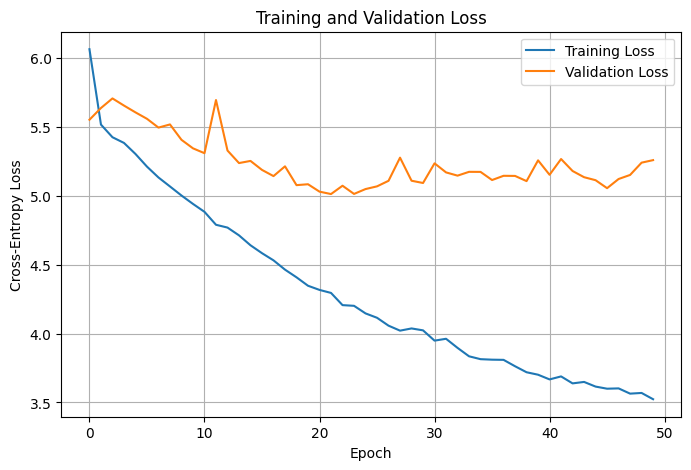

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
def indexes_to_words(indexes, index_to_word):
    words = []

    for idx in indexes:
        if idx in [SOS_token, EOS_token, PAD_token]:
            continue
        words.append(index_to_word.get(idx, "UNK"))

    return words

In [ ]:
def greedy_decode(model, src, max_len, sos_idx, eos_idx, pad_idx, device):
    model.eval()
    with torch.no_grad():
        # Encode the source sequence
        src_padding_mask = (src == pad_idx).to(device)
        src_emb = model.src_embedding(src) * math.sqrt(model.hidden_size)
        src_emb = model.src_pos_encoder(src_emb)
        memory = model.transformer.encoder(src_emb, src_key_padding_mask=src_padding_mask)

        # Initialize target sequence with SOS token
        generated_tokens = [sos_idx]
        tgt_tensor = torch.tensor([sos_idx], dtype=torch.long, device=device).unsqueeze(0) # (1, 1)

        for i in range(max_len):
            tgt_mask = model.make_tgt_mask(tgt_tensor) # Look-ahead mask

            tgt_emb = model.tgt_embedding(tgt_tensor) * math.sqrt(model.hidden_size)
            tgt_emb = model.tgt_pos_encoder(tgt_emb)

            output = model.transformer.decoder(
                tgt_emb,
                memory,
                tgt_mask=tgt_mask,
                tgt_key_padding_mask=None, # No padding in growing target sequence during generation
                memory_key_padding_mask=src_padding_mask
            )

            # Take the last token's output for prediction
            next_token_logits = model.fc_out(output[:, -1, :]) # (1, output_vocab_size)
            next_token = next_token_logits.argmax(dim=-1).item()

            generated_tokens.append(next_token)

            if next_token == eos_idx:
                break

            # Append the predicted token to the target sequence for the next iteration
            tgt_tensor = torch.cat(
                [tgt_tensor, torch.tensor([[next_token]], dtype=torch.long, device=device)], dim=1
            )
        return generated_tokens[1:] # Exclude SOS token

In [ ]:
def evaluate_validation_metrics(model, val_loader, max_length=MAX_LENGTH + 5, n_examples=5):
    model.eval()
    correct_exact_matches = 0
    total_bleu_score = 0.0
    total_samples = 0

    smoothing = SmoothingFunction().method1

    print("\n--- Validation Examples ---")

    with torch.no_grad():
        for i, (input_tensor, target_tensor) in enumerate(val_loader):
            # Iterate through each sample in the batch
            for j in range(input_tensor.size(0)):
                src_sample = input_tensor[j].unsqueeze(0)  # (1, seq_len)
                tgt_sample = target_tensor[j]  # (seq_len)

                predicted_indices_list = greedy_decode(
                    model,
                    src_sample,
                    max_len=max_length,
                    sos_idx=SOS_token,
                    eos_idx=EOS_token,
                    pad_idx=PAD_token,
                    device=device
                )

                # Convert predicted indices to words, filtering special tokens
                input_indices = src_sample.squeeze(0).cpu().tolist()
                target_indices = tgt_sample.cpu().tolist()

                input_words = [
                    index_to_french.get(idx, "UNK")
                    for idx in input_indices
                  if idx not in [SOS_token, EOS_token, PAD_token]
                ]

                target_words = [
                    index_to_english.get(idx, "UNK")
                    for idx in target_indices
                    if idx not in [SOS_token, EOS_token, PAD_token]
                ]

                predicted_words = [
                    index_to_english.get(idx, "UNK")
                    for idx in predicted_indices_list
                    if idx not in [SOS_token, EOS_token, PAD_token]
                ]

                if predicted_words == target_words:
                    correct_exact_matches += 1

                # sentence_bleu expects a list of reference sentences and a candidate sentence
                # each sentence should be a list of tokens
                if len(target_words) > 0 and len(predicted_words) > 0:  # Avoid BLEU calculation for empty sentences
                    bleu = sentence_bleu(
                        [target_words],
                        predicted_words,
                        weights=(0.25, 0.25, 0.25, 0.25),
                        smoothing_function=smoothing
                    )
                else:
                    bleu = 0.0  # If either target or predicted is empty, BLEU is 0

                total_bleu_score += bleu
                total_samples += 1

                if total_samples <= n_examples:  # Display only n_examples
                    print(f"Input:     {' '.join(input_words)}")
                    print(f"Target:    {' '.join(target_words)}")
                    print(f"Predicted: {' '.join(predicted_words)}")
                    print(f"BLEU-4:    {bleu:.4f}")
                    print("-" * 60)

    exact_accuracy = correct_exact_matches / total_samples
    avg_bleu = total_bleu_score / total_samples

    print("\nFinal Validation Metrics:")
    print(f"Traditional Exact-Match Accuracy: {exact_accuracy * 100:.2f}%")
    print(f"Average Validation BLEU-4 Score: {avg_bleu:.4f}")

    return exact_accuracy, avg_bleu

In [ ]:
exact_accuracy, avg_bleu = evaluate_validation_metrics(
    model,
    val_loader
)


--- Validation Examples ---
Input:     elle a gagné un match de tennis
Target:    she won a tennis match
Predicted: she loves a wear
BLEU-4:    0.0744
------------------------------------------------------------
Input:     le marché biologique ouvre à UNK le UNK
Target:    the organic market opens at UNK on UNK
Predicted: the coffee is is is is is
BLEU-4:    0.0286
------------------------------------------------------------
Input:     nous regardons un film ensemble
Target:    we watch a movie together
Predicted: we are going to the park
BLEU-4:    0.0408
------------------------------------------------------------
Input:     le pain de cette boulangerie est toujours UNK
Target:    the bread at this bakery is always UNK
Predicted: the is is is is is is is is
BLEU-4:    0.0285
------------------------------------------------------------
Input:     nous UNK au mariage
Target:    we dance at the wedding
Predicted: we are to the park
BLEU-4:    0.0639
------------------------------------